<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/USDA_FOOD_DATABASE_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**USDA FOOD DATABASE ANALYSIS**

#**1.Định nghĩa vấn đề**

**a) Mô tả**
  + Phạm vi: Cơ sở dữ liệu dinh dưỡng thực phẩm toàn diện của Bộ Nông nghiệp Hoa Kỳ (USDA)
  + Kích thước: 6,636 loại thực phẩm với 375,176 bản ghi chất dinh dưỡng sau khi xử lý
  + Đặc điểm: Dữ liệu đa chiều về thành phần dinh dưỡng, định lượng phần ăn, và phân loại thực phẩm

**b) Dữ liệu vào**

***Thông tin cơ bản (Info DataFrame):***

  - id: ID duy nhất của thực phẩm (Int64)

  - description: Tên đầy đủ của thực phẩm (Object)

  - group: Nhóm thực phẩm chính (Object)

  - manufacturer: Nhà sản xuất (Object)

  - tags: Thẻ phân loại (Object)

***Thông tin dinh dưỡng (Nutrients DataFrame):***

  - id: ID thực phẩm liên kết (Int64)

  - value: Giá trị dinh dưỡng (Float64)

  - units: Đơn vị đo lường (Object)

  - description: Tên chất dinh dưỡng (Object)

  - group: Nhóm chất dinh dưỡng (Object)

***Thông tin định lượng (Portions):***

  - amount: Số lượng phần ăn (Float64)

  - unit: Đơn vị phần ăn (Object)

  - grams: Trọng lượng tương đương theo gram (Float64)


**c) Dữ liệu ra (Kết quả phân tích)**

**Các insight về dinh dưỡng và thực phẩm:**

- Phân bổ dinh dưỡng across các nhóm thực phẩm

- So sánh giá trị dinh dưỡng giữa các thực phẩm

- Mối quan hệ giữa các chất dinh dưỡng

- Xu hướng dinh dưỡng theo nhóm thực phẩm


#**2.Chuẩn bị dữ liệu**

##**2.1.Khai báo thư viện.**

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import json

##**2.2.Nạp dữ liệu.**

In [103]:
import pandas as pd
import requests
url = "https://raw.githubusercontent.com/wesm/pydata-book/3rd-edition/datasets/usda_food/database.json"

db = pd.read_json(url)
display(db.head())

,id,description,tags,manufacturer,group,portions,nutrients
0,1008,"Cheese, caraway",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}]","[{'value': 25.18, 'units': 'g', 'description':..."
1,1009,"Cheese, cheddar",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'cup, diced', 'grams': ...","[{'value': 24.9, 'units': 'g', 'description': ..."
2,1018,"Cheese, edam",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}, ...","[{'value': 4.22, 'units': 'g', 'description': ..."
3,1019,"Cheese, feta",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'cup, crumbled', 'grams...","[{'value': 5.2, 'units': 'g', 'description': '..."
4,1028,"Cheese, mozzarella, part skim milk",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}]","[{'value': 3.27, 'units': 'g', 'description': ..."


In [104]:
# In ra số lượng dòng dữ liệu trong DataFrame
len(db)

6636

##**2.3 Xử Lý Dữ Liệu Trước Khi Gộp (Merge)**
Trước khi gộp (merge) hai DataFrame info (thông tin thực phẩm) và nutrients (thành phần dinh dưỡng), cần xử lý dữ liệu để tránh lỗi và đảm bảo tính nhất quán.

###**2.3.1.TẠO INFO DATAFRAME - Thông tin cơ bản về thực phẩm**

In [105]:
info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)

**Giải thích:**

- info_keys: Chọn 4 trường quan trọng từ dữ liệu gốc: description(mô tả), group, id, manufacturer(nhà sản xuất)

- Tạo DataFrame info chỉ chứa các trường này

**Kết quả:** Mỗi dòng là 1 thực phẩm với thông tin cơ bản

###**2.3.2.TẠO NUTRIENTS DATAFRAME - Ghép dữ liệu dinh dưỡng**

In [85]:
nutrients = []
for index, rec in db.iterrows():  # Lặp qua từng dòng trong db
    fnuts = pd.DataFrame(rec["nutrients"])  # Biến nutrients thành DataFrame nhỏ
    fnuts["id"] = rec["id"]  # Thêm ID để biết nutrients của thực phẩm nào
    nutrients.append(fnuts)  # Thêm vào danh sách

nutrients = pd.concat(nutrients, ignore_index=True)  # Ghép tất cả thành 1 bảng lớn

**Giải thích:**

- Mỗi thực phẩm có 1 list nutrients(chất dinh dưỡng) → biến mỗi list thành DataFrame nhỏ

- Thêm cột id để theo dõi nutrients thuộc về thực phẩm nào

- pd.concat(): Ghép tất cả DataFrame nhỏ thành 1 bảng lớn

###**2.3.3.LÀM SẠCH DỮ LIỆU - Loại bỏ trùng lặp**

In [86]:
print(nutrients.duplicated().sum())  # Đếm số bản ghi trùng
nutrients = nutrients.drop_duplicates()  # Xóa bản ghi trùng

14179


**Giải thích:**

- Kiểm tra và loại bỏ dữ liệu trùng lặp để đảm bảo tính chính xác

- Tránh làm sai lệch kết quả phân tích

###**2.3.4.CHUẨN HÓA TÊN CỘT - Tránh xung đột**

In [87]:
# Đổi tên trong info
col_mapping_info = {"description": "food", "group": "fgroup"}
info = info.rename(columns=col_mapping_info, copy=False)

# Đổi tên trong nutrients
col_mapping_nut = {"description": "nutrient", "group": "nutgroup"}
nutrients = nutrients.rename(columns=col_mapping_nut, copy=False)

**Tại sao cần làm điều này?**

- Cả 2 DataFrame đều có cột description và group

- Khi merge sẽ bị xung đột → sinh ra description_x, description_y

- Đổi tên để phân biệt rõ ràng:

  - food: tên thực phẩm

  - nutrient: tên chất dinh dưỡng

  - fgroup: nhóm thực phẩm

  - nutgroup: nhóm chất dinh dưỡng

###**2.3.5.KIỂM TRA KẾT QUẢ**

In [88]:
print(info.head())  # Xem 5 dòng đầu của info
display(nutrients.head())  # Hiển thị đẹp 5 dòng đầu của nutrients

                                 food                  fgroup    id  \
0                     Cheese, caraway  Dairy and Egg Products  1008   
1                     Cheese, cheddar  Dairy and Egg Products  1009   
2                        Cheese, edam  Dairy and Egg Products  1018   
3                        Cheese, feta  Dairy and Egg Products  1019   
4  Cheese, mozzarella, part skim milk  Dairy and Egg Products  1028   

  manufacturer  
0               
1               
2               
3               
4               


,value,units,nutrient,nutgroup,id
0,25.18,g,Protein,Composition,1008
1,29.20,g,Total lipid (fat),Composition,1008
2,3.06,g,"Carbohydrate, by difference",Composition,1008
3,3.28,g,Ash,Other,1008
4,376.00,kcal,Energy,Energy,1008


###**2.3.6.MERGE Info và Nutrients**

In [89]:
ndata = pd.merge(nutrients, info, on="id")
display(ndata)

,value,units,nutrient,nutgroup,id,food,fgroup,manufacturer
0,25.180,g,Protein,Composition,1008,"Cheese, caraway",Dairy and Egg Products,
1,29.200,g,Total lipid (fat),Composition,1008,"Cheese, caraway",Dairy and Egg Products,
2,3.060,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",Dairy and Egg Products,
3,3.280,g,Ash,Other,1008,"Cheese, caraway",Dairy and Egg Products,
4,376.000,kcal,Energy,Energy,1008,"Cheese, caraway",Dairy and Egg Products,
...,...,...,...,...,...,...,...,...
375171,0.000,mcg,"Vitamin B-12, added",Vitamins,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375172,0.000,mg,Cholesterol,Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375173,0.072,g,"Fatty acids, total saturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375174,0.028,g,"Fatty acids, total monounsaturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None


**Sau merge trên key "id", ta có ndata (375,176 rows, 8 cột), dữ liệu trở nên thống nhất và dễ khai thác:**

- Thuận lợi phân tích đa biến: Có thể groupby trực tiếp theo "nutrient" và "fgroup" mà không cần join thủ công, ví dụ tính median value nhanh chóng.

- Giảm lỗi và tăng tính rõ ràng: Tên cột riêng biệt (food vs. nutrient) tránh nhầm lẫn.

- Insight toàn diện: Kết hợp info và nutrients giúp xem nutrient(chất dinh dưỡng) theo ngữ cảnh food group(food group), ví dụ: Beef Products giàu Zinc hơn Vegetables.

##**3.4 Xử lý dữ liệu trước khi phân tích đơn biến**

In [90]:
#ghép tất cả dữ liệu dinh dưỡng từ 6,636 thực phẩm thành một bảng duy nhấ
nutrients = []
for index, rec in db.iterrows():
    fnuts = pd.DataFrame(rec["nutrients"])
    fnuts["id"] = rec["id"]
    nutrients.append(fnuts)
nutrients = pd.concat(nutrients, ignore_index=True)
print(nutrients.shape)


(389355, 5)


- 389,355 dòng: Tổng số chất dinh dưỡng từ tất cả thực phẩm

- 5 cột: value, units, description, group, id

In [91]:
#PHÁT HIỆN DỮ LIỆU TRÙNG
print(nutrients.duplicated().sum())  # Đếm số bản ghi trùng

14179


- Có 14,179 bản ghi trùng lặp hoàn toàn

- Nguyên nhân: Có thể cùng một chất dinh dưỡng xuất hiện nhiều lần cho cùng thực phẩm

In [92]:
#LÀM SẠCH DỮ LIỆU
nutrients = nutrients.drop_duplicates()  # Xóa các bản ghi trùng
print(nutrients.shape)

(375176, 5)


Kết quả: Giảm từ 389,355 xuống còn 375,176 dòng

#**3. Mô Tả Thống Kê**

Phần này mô tả cấu trúc dữ liệu ban đầu, bao gồm kích thước, missing values, và phân bố cơ bản.

##**3.1 Hiển Thị Mô Tả Thống Kê Với Dữ Liệu**
Tạo DataFrame info từ các trường chính (description, group, id, manufacturer) và kiểm tra info.

In [93]:
info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)
display(info.head())

print("---------------------------------------------------------")
print("số lượng giá trị bị thiếu (missing values) trong từng cột của DataFrame info")
display(info.isnull().sum()) # Output: Chi tiết về columns, non-null counts, dtypes

,description,group,id,manufacturer
0,"Cheese, caraway",Dairy and Egg Products,1008,
1,"Cheese, cheddar",Dairy and Egg Products,1009,
2,"Cheese, edam",Dairy and Egg Products,1018,
3,"Cheese, feta",Dairy and Egg Products,1019,
4,"Cheese, mozzarella, part skim milk",Dairy and Egg Products,1028,


---------------------------------------------------------
số lượng giá trị bị thiếu (missing values) trong từng cột của DataFrame info


,0
description,0
group,0
id,0
manufacturer,1441


- Tổng entries: 6636.
- Cột manufacturer có 1,441 giá trị thiếu

-->Việc có cần xử lý dữ liệu thiếu trong cột manufacturer hay không phụ thuộc vào mục tiêu phân tích


##**3.2 Hiển thị nhóm thực phẩm phổ biến trong dataset.**

In [94]:
pd.value_counts(info["group"])[:10]

/tmp/ipython-input-3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


,count
group,
Vegetables and Vegetable Products,812
Beef Products,618
Baked Products,496
Breakfast Cereals,403
Legumes and Legume Products,365
Fast Foods,365
"Lamb, Veal, and Game Products",345
Sweets,341
Fruits and Fruit Juices,328


#**4.EDA Và Trực Quan Hóa Dữ Liệu**

##**4.1 Phân Tích Đơn Biến (Univariate Analysis)**
Phần này giúp chúng ta hiểu rõ từng khía cạnh dữ liệu một cách riêng lẻ, trước khi khám phá mối quan hệ giữa chúng.

**Câu hỏi 1: Phân bố của các nhóm thực phẩm (fgroup) như thế nào? Điều này sẽ giúp chúng ta hiểu hơn về cấu trúc dữ liệu chính và tỷ lệ các loại thực phẩm.**

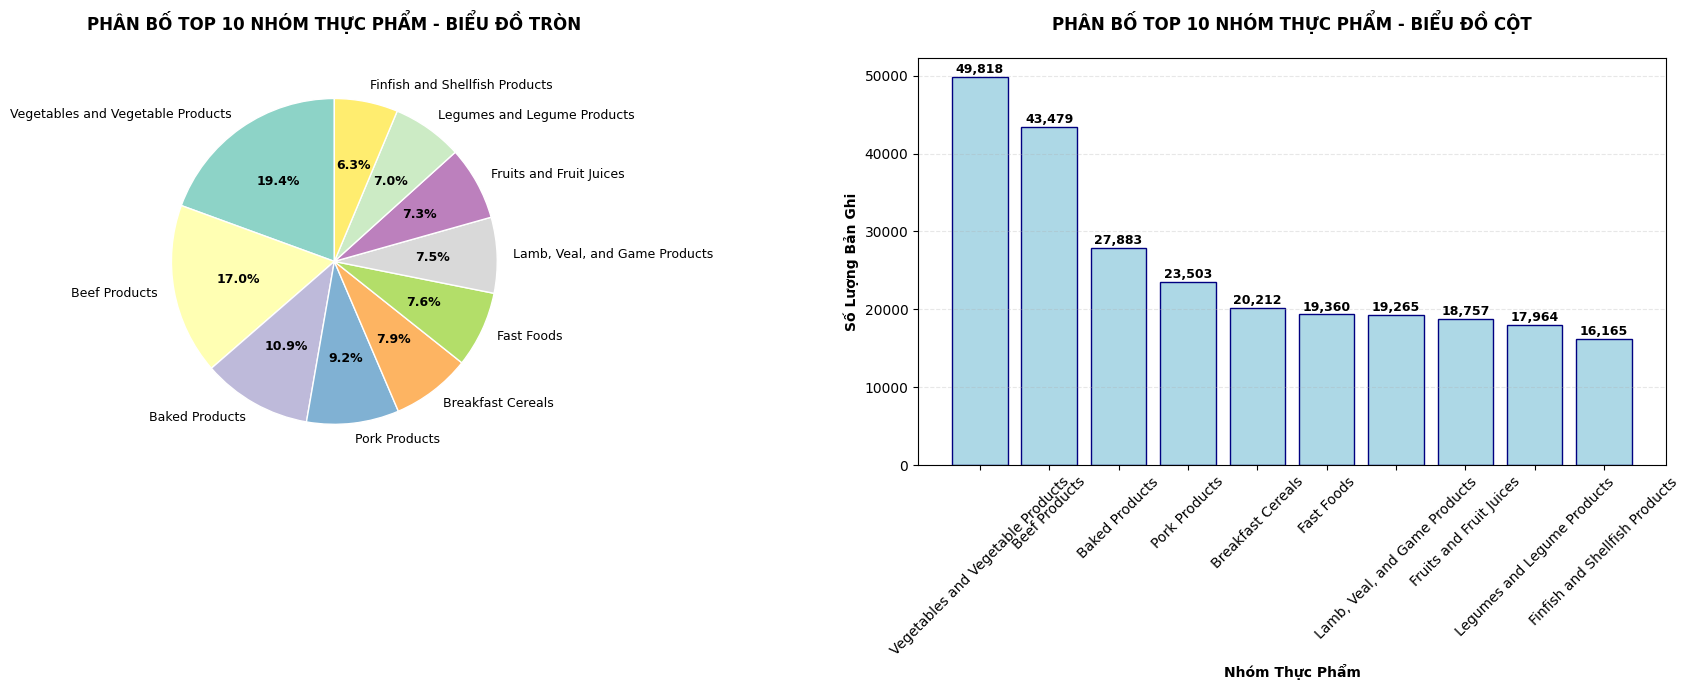

In [95]:
fgroup_dist = ndata['fgroup'].value_counts().head(10)

# Tạo figure với 2 subplot cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# BIỂU ĐỒ TRÒN (trái)
colors = plt.cm.Set3(np.linspace(0, 1, len(fgroup_dist)))
wedges, texts, autotexts = ax1.pie(fgroup_dist.values,
                                  labels=fgroup_dist.index,
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  textprops={'fontsize': 9},
                                  wedgeprops={'edgecolor': 'w', 'linewidth': 1})

ax1.set_title('PHÂN BỐ TOP 10 NHÓM THỰC PHẨM - BIỂU ĐỒ TRÒN', fontsize=12, fontweight='bold', pad=20)

# Tùy chỉnh phần trăm
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# BIỂU ĐỒ CỘT (phải)
bars = ax2.bar(fgroup_dist.index, fgroup_dist.values, color='lightblue', edgecolor='navy')
ax2.set_title('PHÂN BỐ TOP 10 NHÓM THỰC PHẨM - BIỂU ĐỒ CỘT', fontsize=12, fontweight='bold', pad=20)
ax2.set_xlabel('Nhóm Thực Phẩm', fontweight='bold')
ax2.set_ylabel('Số Lượng Bản Ghi', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu lên các cột
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**Nhóm chiếm ưu thế:**

- Rau củ & Sản phẩm từ rau dẫn đầu (19.4%) - phản ánh tính đa dạng và quan trọng của nhóm này

- Sản phẩm thịt bò (17.0%) - nhóm protein động vật phổ biến nhất

- Sản phẩm nướng (10.9%) - thực phẩm chế biến sẵn chiếm tỷ trọng đáng kể

**Câu hỏi 2: Nhóm chất dinh dưỡng nào chiếm tỷ lệ lớn trong cơ sở dữ liệu USDA?**

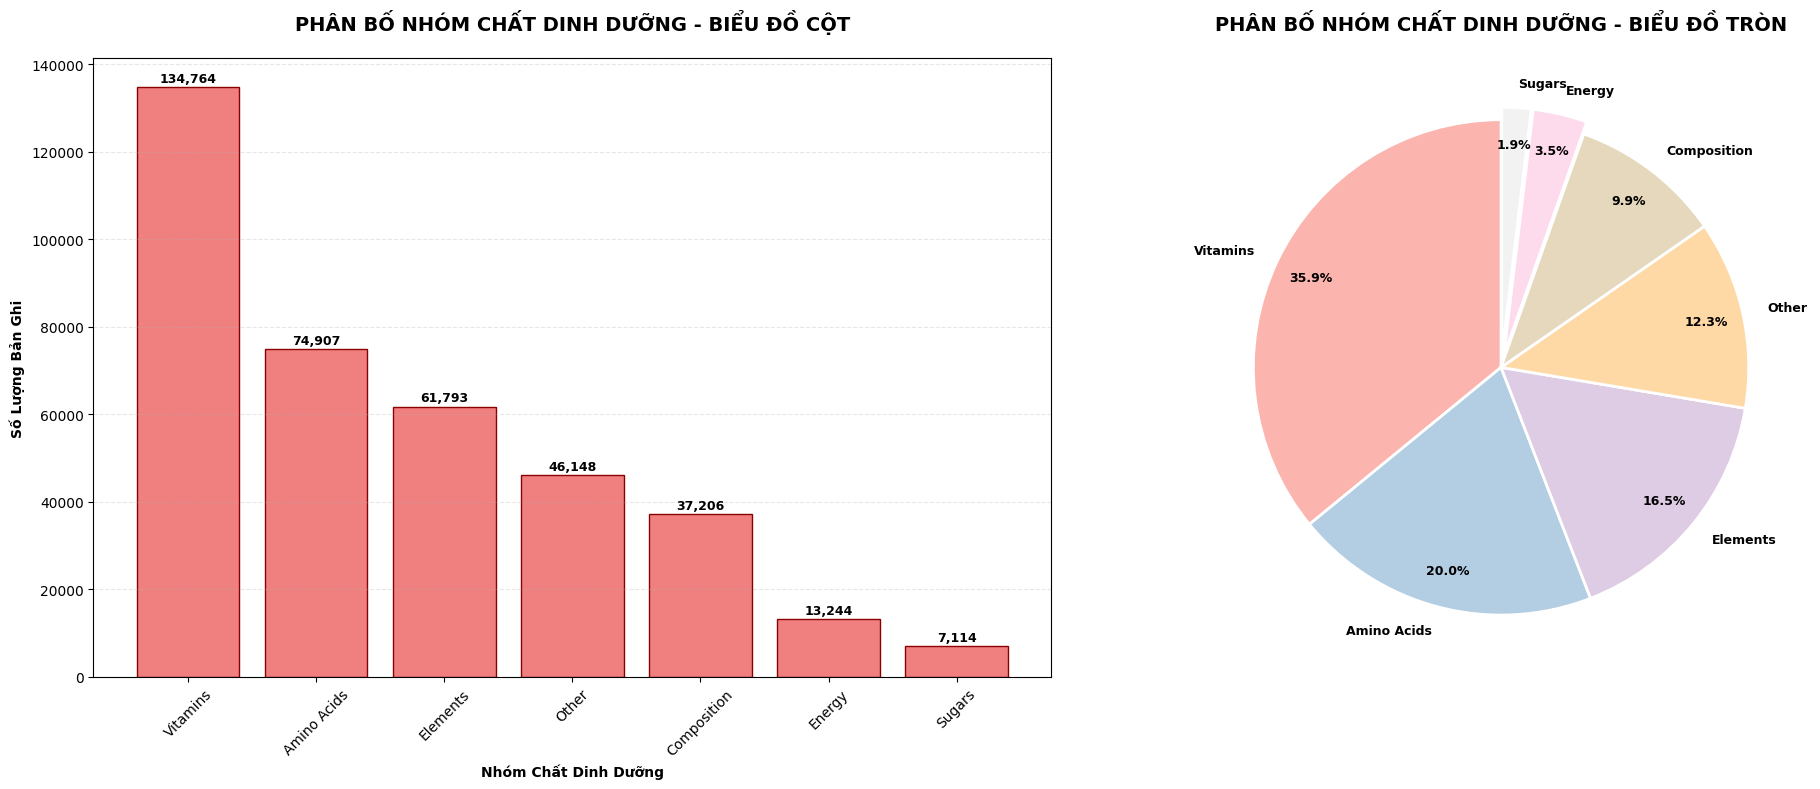

In [96]:
import matplotlib.pyplot as plt
import numpy as np

nutgroup_dist = ndata['nutgroup'].value_counts()

# Tạo figure với 2 subplot cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# BIỂU ĐỒ CỘT (trái)
bars = ax1.bar(nutgroup_dist.index, nutgroup_dist.values, color='lightcoral', edgecolor='darkred')
ax1.set_title('PHÂN BỐ NHÓM CHẤT DINH DƯỠNG - BIỂU ĐỒ CỘT', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Nhóm Chất Dinh Dưỡng', fontweight='bold')
ax1.set_ylabel('Số Lượng Bản Ghi', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu lên các cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# BIỂU ĐỒ TRÒN (phải) - Sửa lỗi chữ đè lên nhau
colors = plt.cm.Pastel1(np.linspace(0, 1, len(nutgroup_dist)))

# Tính toán khoảng cách cho các phần nhỏ để tránh đè chữ
explode = [0.05 if (count/np.sum(nutgroup_dist.values)) < 0.05 else 0 for count in nutgroup_dist.values]

wedges, texts, autotexts = ax2.pie(nutgroup_dist.values,
                                  labels=nutgroup_dist.index,
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  explode=explode,  # Thêm khoảng cách cho phần nhỏ
                                  textprops={'fontsize': 9, 'fontweight': 'bold'},
                                  wedgeprops={'edgecolor': 'w', 'linewidth': 2},
                                  pctdistance=0.85)  # Đẩy phần trăm vào trong

ax2.set_title('PHÂN BỐ NHÓM CHẤT DINH DƯỠNG - BIỂU ĐỒ TRÒN', fontsize=14, fontweight='bold', pad=20)

# Tùy chỉnh phần trăm trong biểu đồ tròn
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Điều chỉnh vị trí các nhãn để tránh đè lên nhau
for text in texts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Nhóm chiếm ưu thế:**
- Vitamins dẫn đầu rõ rệt (35.9%) - Cho thấy cơ sở dữ liệu USDA rất chi tiết về vi chất dinh dưỡng,

- Amino Acids (20.0%) - Quan tâm đến chất lượng protein

- Elements (16.5%) - Khoáng chất đa lượng và vi lượng

- Other (12.3%) - Các hợp chất đặc biệt khác

##**4.2. Phân Tích Đa Biến (Multivariate Analysis)**

**Câu hỏi 1: Nhóm thực phẩm nào có hàm lượng kẽm cao nhất và thấp nhất? Sự chênh lệch này lớn tới mức nào?**

In [97]:
result = ndata.groupby(["nutrient", "fgroup"])["value"].quantile(0.5)

<BarContainer object of 25 artists>

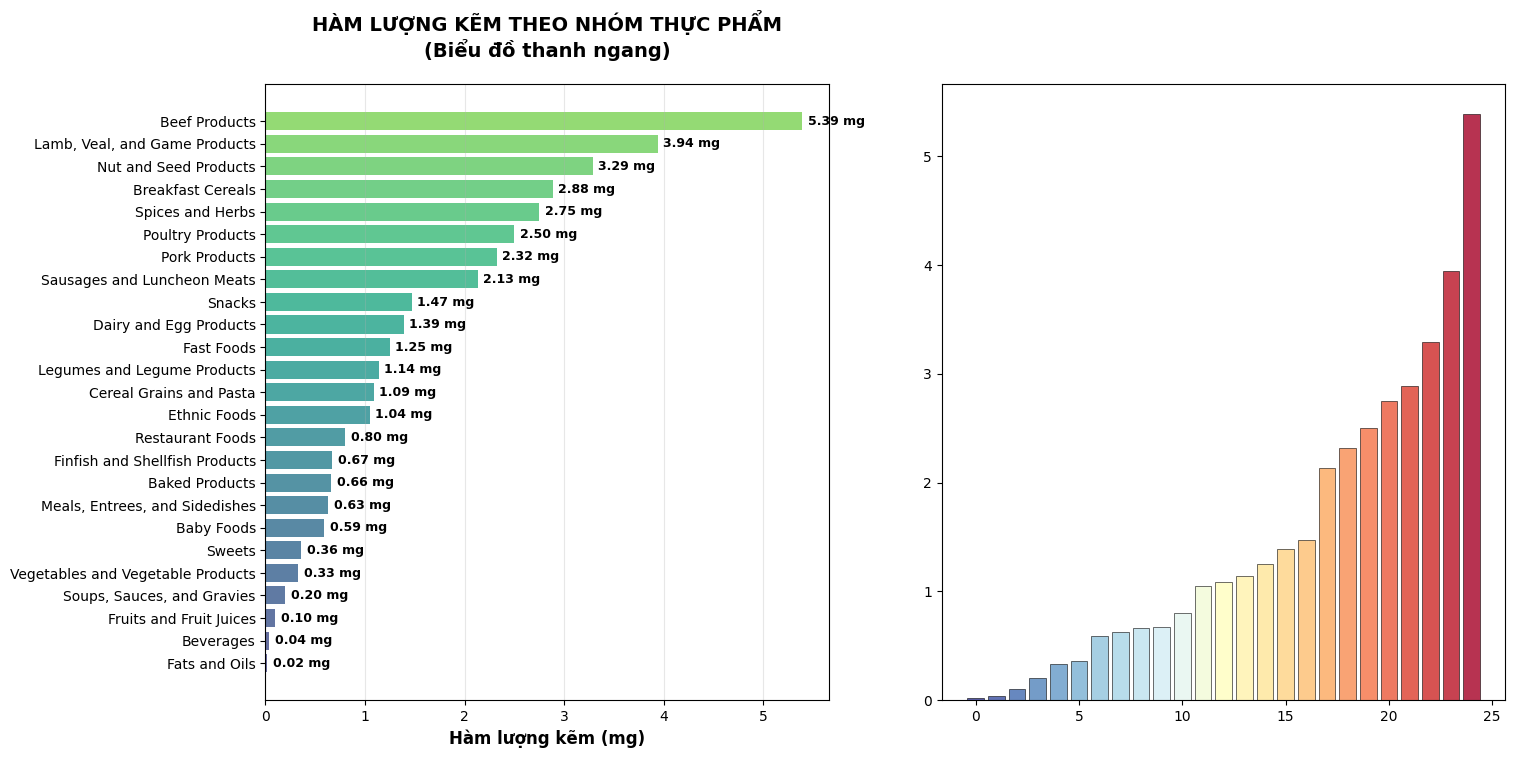

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Lấy dữ liệu kẽm
zinc_data = result["Zinc, Zn"].sort_values(ascending=True)  # Sắp xếp tăng dần để biểu đồ ngang dễ nhìn

# Tạo figure với 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# BIỂU ĐỒ 1: BAR CHART NGANG
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(zinc_data)))
bars = ax1.barh(range(len(zinc_data)), zinc_data.values, color=colors, alpha=0.8)

# Thêm giá trị trên các cột
for i, (bar, value) in enumerate(zip(bars, zinc_data.values)):
    ax1.text(value + max(zinc_data.values)*0.01, i, f'{value:.2f} mg',
             va='center', fontweight='bold', fontsize=9)

ax1.set_yticks(range(len(zinc_data)))
ax1.set_yticklabels(zinc_data.index, fontsize=10)
ax1.set_xlabel('Hàm lượng kẽm (mg)', fontweight='bold', fontsize=12)
ax1.set_title('HÀM LƯỢNG KẼM THEO NHÓM THỰC PHẨM\n(Biểu đồ thanh ngang)',
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# BIỂU ĐỒ 2: BAR CHART DỌC CÓ MÀU PHÂN CẤP
ax2.bar(range(len(zinc_data)), zinc_data.values,
        color=plt.cm.RdYlBu_r(np.linspace(0, 1, len(zinc_data))),
        alpha=0.8, edgecolor='black', linewidth=0.5)

**Từ biểu đồ hàm lượng kẽm, ta có khuyến nghị cụ thể:**

- **CHO NGƯỜI THIẾU KẼM**

  - Beef Products (5.39mg) - Thịt bò các loại

  - Lamb, Veal (3.94mg) - Thịt cừu, thịt bê

  - Nut and Seed Products (3.29mg) - Các loại hạt

  - Breakfast Cereals (2.88mg) - Ngũ cốc ăn sáng

  - Poultry Products (2.50mg) - Thịt gia cầm

**Câu hỏi 2: Dựa trên dữ liệu này, người ăn chay trường họ có thể bổ sung kẽm từ những nguồn thực vật nào có hàm lượng cao nhất trong biểu đồ?**

- **NGUỒN KẼM THAY THẾ CHO NGƯỜI ĂN CHAY**

  - Nut and Seed Products (3.29mg) - HẠT CÁC LOẠI

  - Breakfast Cereals (2.88mg) - NGŨ CỐC NGUYÊN HẠT

  - Legumes (1.14mg) - ĐẬU CÁC LOẠI



bảng thực phẩm có hàm lượng amino acid cao nhất

In [99]:
by_nutrient = ndata.groupby(["nutgroup", "nutrient"])
def get_maximum(x):
 return x.loc[x.value.idxmax()]
max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]
# make the food a little smaller
max_foods["food"] = max_foods["food"].str[:50]

/tmp/ipython-input-1417839404.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]


In [100]:
max_foods.loc["Amino Acids"]["food"]

,food
nutrient,
Alanine,"Gelatins, dry powder, unsweetened"
Arginine,"Seeds, sesame flour, low-fat"
Aspartic acid,Soy protein isolate
Cystine,"Seeds, cottonseed flour, low fat (glandless)"
Glutamic acid,Soy protein isolate
Glycine,"Gelatins, dry powder, unsweetened"
Histidine,"Whale, beluga, meat, dried (Alaska Native)"
Hydroxyproline,"KENTUCKY FRIED CHICKEN, Fried Chicken, ORIGINA..."
Isoleucine,"Soy protein isolate, PROTEIN TECHNOLOGIES INTE..."


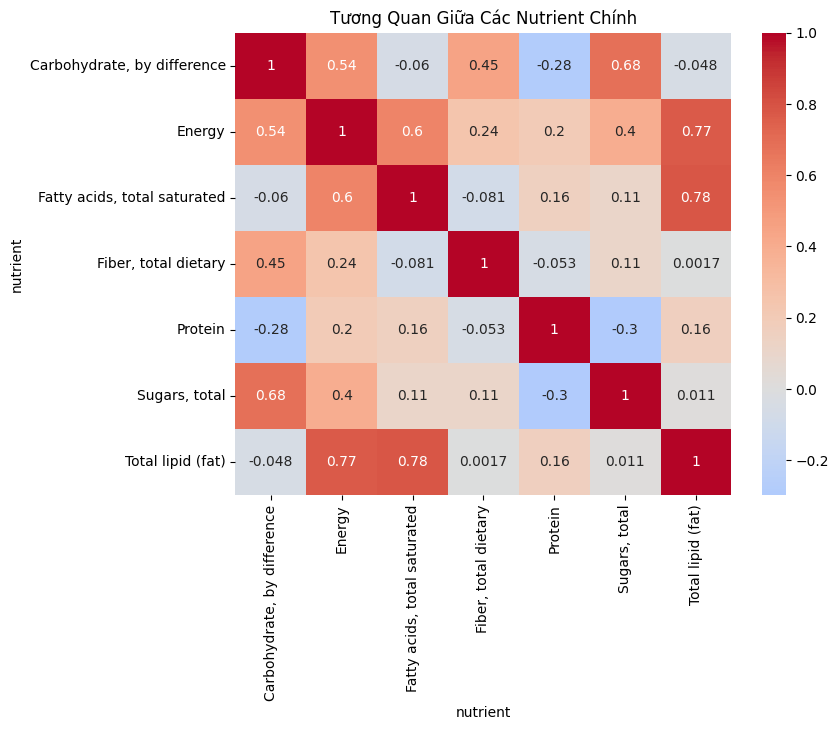

In [101]:
key_nutrients = ['Energy', 'Total lipid (fat)', 'Carbohydrate, by difference', 'Protein', 'Sugars, total', 'Fatty acids, total saturated', 'Fiber, total dietary']
key_data = ndata[ndata['nutrient'].isin(key_nutrients)]
pivot_corr = key_data.pivot_table(values='value', index='id', columns='nutrient').corr()
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Tương Quan Giữa Các Nutrient Chính')
plt.show()

**Chỉ số tương quan giữa "Total lipid (fat)" và "Energy" là 0.77.**

- **Tại sao lại như vậy?**
  - Về mặt dinh dưỡng, điều này là hoàn to hợp lý vì chất béo là nguồn cung cấp năng lượng đậm đặc nhất. Cụ thể:

    - 1g Chất béo cung cấp 9 kcal.

    - Trong khi đó, 1g Carbohydrate hoặc 1g Protein chỉ cung cấp 4 kcal.

   - Vì vậy, khi một thực phẩm có hàm lượng chất béo (Total lipid) cao, nó chắc chắn sẽ có hàm lượng năng lượng (Energy) cao, và con số 0.77 trong bảng đã xác nhận mối quan hệ chặt chẽ này

**Chỉ số tương quan giữa 'Fatty acids, total saturated' và 'Total lipid (fat)'  là 0.78.**

**Giải thích:**

- Giá trị 0.78 cho thấy một mối tương quan thuận rất chặt chẽ. Điều này có nghĩa là:

  - Khi hàm lượng Tổng chất béo (Total lipid) trong một loại thực phẩm tăng lên, thì hàm lượng Chất béo bão hòa (Fatty acids, total saturated) trong thực phẩm đó cũng có xu hướng tăng theo.

  - Và ngược lại, thực phẩm ít chất béo nói chung thì cũng thường ít chất béo bão hòa.

**Chỉ số tương quan giữa  'Carbohydrate, by difference' và 'Sugars, total' là 0.68.**

**Giải thích từ góc độ dinh dưỡng:**

- Mối tương quan "khá mạnh" (0.68) thay vì "rất mạnh" (trên 0.8) cho thấy:

  - Có những thực phẩm carbohydrate cao chủ yếu là tinh bột (như cơm, bánh mì, mì ít đường) thì có thể có hàm lượng đường không cao.

  - Có những thực phẩm carbohydrate cao chủ yếu là đường (như kẹo, nước ngọt, trái cây sấy) nên làm cho mối tương quan này trở nên chặt chẽ hơn.



# **5.Kết luận:**

**Dữ liệu cho thấy rõ ràng về mối quan hệ giữa các nhóm chất:**

- Năng lượng (Calo) chủ yếu đến từ Chất béo, và phần lớn lượng chất béo đó lại là Chất béo bão hòa - loại chất béo không có lợi cho sức khỏe.

- Đường là một thành phần chính của Carbohydrate, nhưng không phải là tất cả. Vẫn có những nguồn carb tốt (ngũ cốc nguyên hạt, đậu) ít đường.

=> Điều này giải thích tại sao các chế độ ăn nhiều thực phẩm chế biến sẵn, đồ chiên rán và thịt mỡ (vừa nhiều chất béo bão hòa vừa nhiều năng lượng) lại dễ dẫn đến thừa cân, béo phì và các bệnh tim mạch.

**GIẢI PHÁP CỤ THỂ**

**Để có một chế độ dinh dưỡng lành mạnh, cân bằng, bạn nên áp dụng các nguyên tắc sau:**

**1. Giải pháp về CHẤT BÉO & NĂNG LƯỢNG**

  - Ưu tiên chất béo tốt: Thay thế nguồn chất béo từ mỡ động vật, đồ chiên rán bằng các nguồn chất béo không bão hòa có lợi.

    - Ví dụ: Dùng dầu ô liu, dầu hạt cải để nấu ăn.

    - Ăn các loại hạt (hạnh nhân, óc chó) và quả bơ.

    - Ăn cá béo (cá hồi, cá thu) ít nhất 2 lần/tuần.

  - Kiểm soát tổng lượng: Chọn phương pháp chế biến ít béo (hấp, luộc, nướng) thay vì chiên xào. Đọc nhãn thực phẩm để chọn sản phẩm ít chất béo bão hòa.

**2. Giải pháp về CARBOHYDRATE & ĐƯỜNG**

Chọn Carb thông minh: Hãy phân biệt rõ giữa carb tốt và carb xấu.

**Nên ăn:** Ngũ cốc nguyên hạt (gạo lứt, yến mạch), đậu các loại, rau củ. Chúng cung cấp năng lượng ổn định và nhiều chất xơ.

**Hạn chế:** Thực phẩm chứa đường tinh luyện (bánh kẹo, nước ngọt, siro). Chúng cung cấp "calo rỗng" và dễ gây tăng cân.

**3. Giải pháp BỔ SUNG KẼM**

- **Cho người ăn mặn:** Thịt bò, thịt cừu, thịt gia cầm và các loại hạt là nguồn kẽm tuyệt vời.

- **Cho người ăn chay:** Đảm bảo đủ kẽm bằng cách ăn đa dạng các loại hạt (hạt bí, hạt điều), ngũ cốc nguyên hạt, và đậu (đậu lăng, đậu xanh).